<a href="https://colab.research.google.com/github/pharringtonp19/housing-and-homelessness/blob/main/notebooks/nyc_rent_control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Download Data Sets**

In [1]:
!wget -O nyc_hvs_2023_allunits.csv https://www.nyc.gov/assets/hpd/data/allunits_puf_23.csv

--2025-10-10 16:21:45--  https://www.nyc.gov/assets/hpd/data/allunits_puf_23.csv
Resolving www.nyc.gov (www.nyc.gov)... 184.50.178.47, 2600:1417:76:49b::1500, 2600:1417:76:49e::1500
Connecting to www.nyc.gov (www.nyc.gov)|184.50.178.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/csv]
Saving to: ‘nyc_hvs_2023_allunits.csv’

nyc_hvs_2023_alluni     [ <=>                ]  10.28M  --.-KB/s    in 0.09s   

2025-10-10 16:21:46 (110 MB/s) - ‘nyc_hvs_2023_allunits.csv’ saved [10783120]



In [2]:
!wget -O nyc_hvs_2023_person.csv https://www.nyc.gov/assets/hpd/data/person_puf_23.csv

--2025-10-10 16:21:46--  https://www.nyc.gov/assets/hpd/data/person_puf_23.csv
Resolving www.nyc.gov (www.nyc.gov)... 184.50.178.47, 2600:1417:76:49b::1500, 2600:1417:76:49e::1500
Connecting to www.nyc.gov (www.nyc.gov)|184.50.178.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/csv]
Saving to: ‘nyc_hvs_2023_person.csv’

nyc_hvs_2023_person     [  <=>               ]  26.34M  97.4MB/s    in 0.3s    

2025-10-10 16:21:47 (97.4 MB/s) - ‘nyc_hvs_2023_person.csv’ saved [27625058]



### **Import Libraries**

In [28]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata
from matplotlib import font_manager
import matplotlib.dates as mdates
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib import rcParams
rcParams['image.interpolation'] = 'nearest'
rcParams['image.cmap'] = 'viridis'
rcParams['axes.grid'] = False
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.use_locale'] = False
plt.rcParams['axes.formatter.use_mathtext'] = False
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

### **Read In Data**

In [4]:
df = pd.read_csv("nyc_hvs_2023_allunits.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (9597, 116)


,CONTROL,BORO,OCC,CSR,CONDOCOOP,STORIES,ELEVATOR,UNITS,UNIT_FLOOR,UNIT_ONEPLUSFLIGHT,...,FW71,FW72,FW73,FW74,FW75,FW76,FW77,FW78,FW79,FW80
0,12130002,2,1,2,2,6,1,10,5,2,...,442.455446,127.631770,711.527866,132.998833,709.589086,130.988565,736.863209,129.455196,762.451636,119.404255
1,12130005,3,1,80,2,4,1,6,3,2,...,169.052548,553.284761,942.616620,164.975190,931.214014,559.255649,554.254696,560.187235,161.939232,567.640705
2,12130008,3,1,80,3,7,1,10,5,2,...,239.068885,234.129431,71.519095,399.007919,71.703011,234.722388,410.574605,70.158697,393.432862,246.590232
3,12130010,3,1,80,3,5,1,10,1,2,...,230.859408,224.223475,224.530093,232.675383,379.403388,66.640274,222.069717,387.334049,225.783637,232.247668
4,12130011,3,1,2,2,4,1,8,5,2,...,537.958596,521.546224,888.184005,542.202939,149.320506,530.269565,524.148922,518.288581,900.353246,532.630520


In [5]:
df['CSR'].value_counts(normalize=True)

,proportion
CSR,
32,0.333959
80,0.254559
6,0.109722
4,0.073669
5,0.070543
2,0.048140
96,0.037512
97,0.032823
12,0.025633


In [6]:
df['rent_regulated'] = df['CSR'].isin([32, 90])

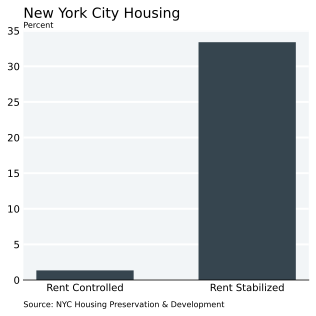

In [7]:
rent_shares = (
    df['CSR']
    .replace({32: 'Rent Stabilized', 90: 'Rent Controlled'})
    .value_counts(normalize=True)
    .loc[['Rent Controlled', 'Rent Stabilized']]
)*100.0

fig = plt.figure(dpi=300, tight_layout=True, figsize=(4.5, 4.5))
ax = plt.axes(facecolor=(.95, .96, .97))
ax.xaxis.set_tick_params(length=0, labeltop=False, labelbottom=True)

for key in 'left', 'right', 'top':
    ax.spines[key].set_visible(False)
ax.text(0., 1.05, s='New York City Housing', transform=ax.transAxes, size=14)
ax.text(0., 1.01, s='Percent', transform=ax.transAxes, size=8)
plt.bar(rent_shares.index, rent_shares.values, color='#36454F', width=0.6)
ax.yaxis.set_tick_params(length=0)
ax.yaxis.grid(True, color='white', linewidth=2)
ax.set_axisbelow(True)
ax.annotate("Source: NYC Housing Preservation & Development",
        xy = (0., -0.1),
        xycoords='axes fraction',
        ha='left',
        va="center",
        fontsize=8)
fig.savefig('./nyc_rent_reg.png')
plt.show()

In [9]:
# Remove invalid income codes (keep only positive values)

df1 = pd.read_csv("nyc_hvs_2023_person.csv")
df1_clean = df1[df1['TOTAL_INC_P'] > 0].copy()

# Recalculate household total income
inc_by_hh = (
    df1_clean
    .groupby('CONTROL')['TOTAL_INC_P']
    .sum()
    .rename('HHINC_from_persons')
)

# Merge back to household-level data
df = df.merge(inc_by_hh, on='CONTROL', how='left')

# Check summary stats again
df['HHINC_from_persons'].describe()

,HHINC_from_persons
count,8.145000e+03
mean,1.356139e+05
std,2.084490e+05
min,1.000000e+00
25%,3.500000e+04
50%,7.900000e+04
75%,1.565000e+05
max,3.777727e+06


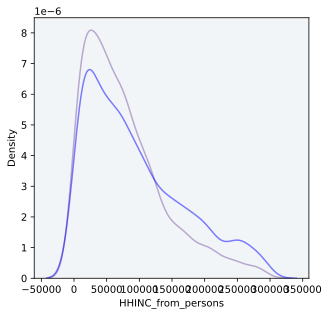

In [35]:
import seaborn as sns
import matplotlib.ticker as mtick

condition = (df['HHINC_from_persons'] > 0) & (df['HHINC_from_persons']<300_000)
df_temp = df[condition]

df_temp.groupby('rent_regulated')['HHINC_from_persons'].mean()
fig = plt.figure(dpi=300, tight_layout=True, figsize=(4.5, 4.5))
ax = plt.axes(facecolor=(.95, .96, .97))
sns.kdeplot(df_temp['HHINC_from_persons'][df_temp['rent_regulated']==True], fill=False, color='#7D5BA6', alpha=0.5, ax=ax)
sns.kdeplot(df_temp['HHINC_from_persons'][df_temp['rent_regulated']==False], fill=False, color='blue', alpha=0.5, ax=ax)
ax.xaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=False))
ax.ticklabel_format(style='plain', axis='x')#plt.xlim(0, 300_000)

plt.show()
# sns.kdeplot(df['HHINC_from_persons'][condition1], fill=True,  alpha=0.5)

# plt.title('Density of Household Income')
# plt.xlabel('Household Income ($)')
# plt.ylabel('Density')
# plt.grid(alpha=0.3)
# plt.show()

In [34]:
condition = (df['HHINC_from_persons'] > 0) & (df['HHINC_from_persons']<300_000)
df_temp = df[condition]
df_temp['HHINC_from_persons'].max()

298650.0